<a href="https://colab.research.google.com/github/rolessia/nm/blob/main/Lab9/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_9_%D0%A0%D0%B0%D0%BA_%D0%9E%D0%BB%D0%B5%D1%81%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 9. Сплайни. Була присутня на парі

Варіант 18

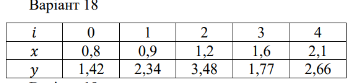



In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0.8, 0.9, 1.2, 1.6, 2.1])
y = np.array([1.42, 2.34, 3.48, 1.77, 2.66])

n = len(x) - 1
h = np.diff(x)
a = y
b = np.zeros(n)
d = np.zeros(n)
c = np.zeros(n + 1)

alpha = np.zeros(n)
for i in range(1, n):
    alpha[i] = (3 / h[i]) * (a[i+1] - a[i]) - (3 / h[i-1]) * (a[i] - a[i-1])

l = np.ones(n + 1)
mu = np.zeros(n)
z = np.zeros(n + 1)

for i in range(1, n):
    l[i] = 2 * (x[i+1] - x[i-1]) - h[i-1] * mu[i-1]
    mu[i] = h[i] / l[i]
    z[i] = (alpha[i] - h[i-1] * z[i-1]) / l[i]

l[n] = 1
z[n] = 0
c[n] = 0

for j in range(n-1, -1, -1):
    c[j] = z[j] - mu[j] * c[j+1]
    b[j] = (a[j+1] - a[j]) / h[j] - h[j] * (c[j+1] + 2 * c[j]) / 3
    d[j] = (c[j+1] - c[j]) / (3 * h[j])

for i in range(n):
    print(f"Відрізок {i+1}:")
    print(f"S_{i}(x) = {a[i]} + {b[i].round(4)}(x - {x[i]}) + {c[i].round(4)}(x - {x[i]})^2 + {d[i].round(4)}(x - {x[i]})^3, x належить [{x[i]}, {x[i+1]}]")

Відрізок 1:
S_0(x) = 1.42 + 9.6436(x - 0.8) + 0.0(x - 0.8)^2 + -44.3621(x - 0.8)^3, x належить [0.8, 0.9]
Відрізок 2:
S_1(x) = 2.34 + 8.3128(x - 0.9) + -13.3086(x - 0.9)^2 + -5.7796(x - 0.9)^3, x належить [0.9, 1.2]
Відрізок 3:
S_2(x) = 3.48 + -1.2329(x - 1.2) + -18.5103(x - 1.2)^2 + 27.2628(x - 1.2)^3, x належить [1.2, 1.6]
Відрізок 4:
S_3(x) = 1.77 + -2.955(x - 1.6) + 14.2051(x - 1.6)^2 + -9.47(x - 1.6)^3, x належить [1.6, 2.1]


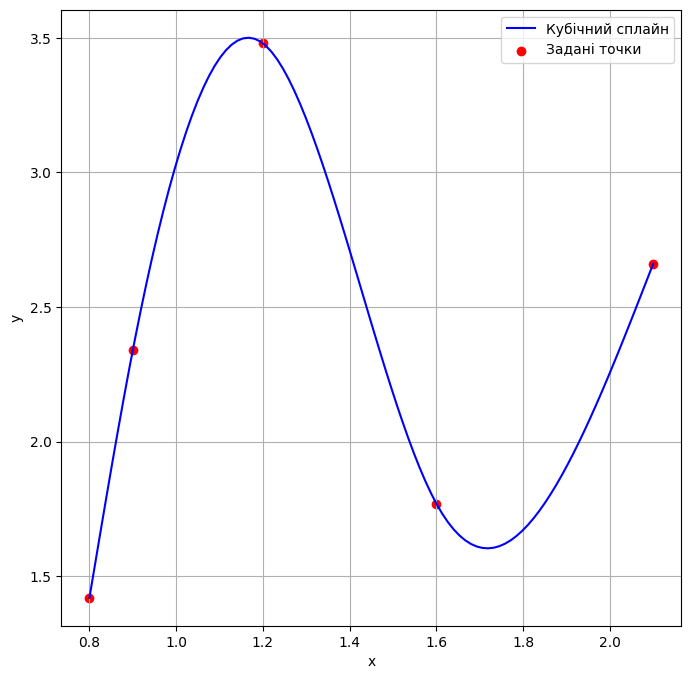

In [2]:
x_values = np.linspace(np.min(x), np.max(x), 100)
y_values = []

for i in range(n):
    mask = (x_values >= x[i]) & (x_values <= x[i + 1])
    x_interval = x_values[mask]
    y_interval = a[i] + b[i] * (x_interval - x[i]) + c[i] * (x_interval - x[i]) ** 2 + d[i] * (x_interval - x[i]) ** 3
    y_values.extend(y_interval)

plt.figure(figsize=(8, 8))
plt.plot(x_values, y_values, label="Кубічний сплайн", color='b')
plt.scatter(x, y, label="Задані точки", color='r')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

2 пара

S_1(x) = -3.5513*(x - 0.8)^3 + -11.7243*(x - 0.8)^2 + 10.4079*(x - 0.8) + 1.4200
S_2(x) = -3.5513*(x - 0.9)^3 + -12.7897*(x - 0.9)^2 + 7.9565*(x - 0.9) + 2.3400
S_3(x) = 17.4721*(x - 1.2)^3 + -15.9859*(x - 1.2)^2 + -0.6762*(x - 1.2) + 3.4800
S_4(x) = 17.4721*(x - 1.6)^3 + 4.9806*(x - 1.6)^2 + -5.0783*(x - 1.6) + 1.7700


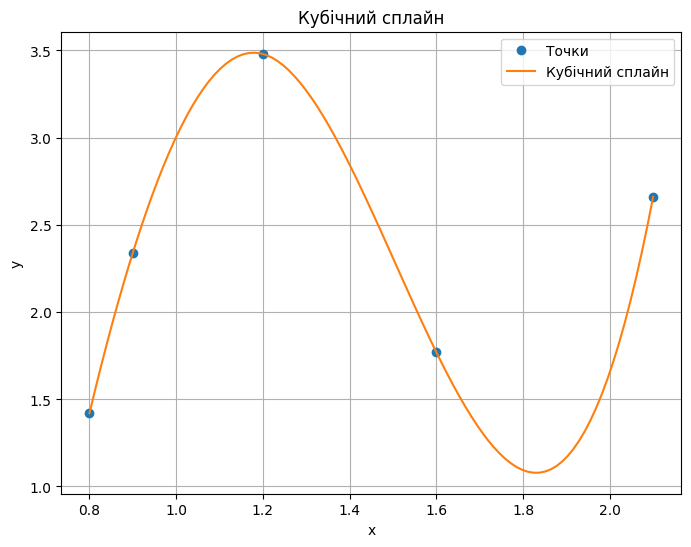

In [3]:
from scipy.interpolate import CubicSpline

x = np.array([0.8, 0.9, 1.2, 1.6, 2.1])
y = np.array([1.42, 2.34, 3.48, 1.77, 2.66])

cs = CubicSpline(x, y)

for i in range(len(x)-1):
    coeffs = cs.c[:, i]
    spline = f'S_{i+1}(x) = {coeffs[0]:.4f}*(x - {x[i]})^3 + {coeffs[1]:.4f}*(x - {x[i]})^2 + {coeffs[2]:.4f}*(x - {x[i]}) + {coeffs[3]:.4f}'
    print(spline)

x_new = np.linspace(np.min(x), np.max(x), 100)
y_new = cs(x_new)

plt.figure(figsize=(8, 6))
plt.plot(x, y, 'o', label='Точки')
plt.plot(x_new, y_new, label='Кубічний сплайн')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Кубічний сплайн')
plt.legend()
plt.grid(True)
plt.show()